<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sagnik/Tree_Based_FL_on_Wine_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Histogram-Based Federated Decision Trees

## Objective

This notebook implements a privacy-aware federated decision tree using histogram aggregation.

Unlike centralized learning, each client keeps its local dataset and shares only aggregated histogram statistics with the server. The server constructs the global decision tree using these histograms without directly accessing individual training samples.

Two aggregation strategies are implemented:

1. Histogram Aggregation
2. Consensus Histogram Aggregation

The experiments are performed on the Wine dataset under multiple statistical heterogeneity settings generated using Dirichlet partitioning.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Loading the Dataset

The Wine dataset contains measurements from three cultivars of wine.

Each sample contains thirteen continuous numerical attributes and belongs to one of three classes.

The dataset is divided into training and testing subsets. Only the training data are distributed among federated clients.

In [ ]:
wine = load_wine()

X = wine.data
y = wine.target

feature_names = wine.feature_names
class_names = wine.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 142
Testing Samples  : 36


# Federated Learning Configuration

The training dataset is partitioned among multiple clients using Dirichlet sampling.

The concentration parameter α controls the degree of statistical heterogeneity.

- Large α → Nearly IID
- Small α → Highly Non-IID

The histogram representation uses a fixed number of bins shared across all clients. These global bins allow local histograms from different clients to be aggregated consistently while preventing direct sharing of raw feature values.

In [ ]:
NUM_CLIENTS = 5

NUM_BINS = 16

NUM_CLASSES = len(np.unique(y_train))

MAX_DEPTH = 5

MIN_SAMPLES_SPLIT = 5

DEFAULT_ALPHA = 0.5

# Creating Federated Clients

Client datasets are generated using Dirichlet partitioning.

Each class is independently divided among the participating clients according to a Dirichlet distribution. Smaller α values create increasingly imbalanced client datasets, simulating realistic Non-IID federated environments.

In [ ]:
def create_dirichlet_clients(
    X,
    y,
    num_clients,
    alpha,
    random_state=42
):

    np.random.seed(random_state)

    num_classes = len(np.unique(y))

    client_indices = [[] for _ in range(num_clients)]

    for cls in range(num_classes):

        indices = np.where(y == cls)[0]

        np.random.shuffle(indices)

        proportions = np.random.dirichlet(
            alpha * np.ones(num_clients)
        )

        split_points = (
            np.cumsum(proportions) * len(indices)
        ).astype(int)[:-1]

        partitions = np.split(indices, split_points)

        for client_id, idx in enumerate(partitions):

            client_indices[client_id].extend(idx)

    clients = []

    for client_id, indices in enumerate(client_indices):

        indices = np.array(indices)

        if len(indices) == 0:
            continue


        clients.append({

            "id": client_id,

            "X": X[indices],

            "y": y[indices]

        })

    return clients

In [ ]:
clients = create_dirichlet_clients(

    X_train,

    y_train,

    NUM_CLIENTS,

    DEFAULT_ALPHA

)

print(f"{len(clients)} Clients Created")

5 Clients Created


# Global Histogram Bins

To aggregate histograms from different clients, every client must use the same bin boundaries.

The server computes global feature ranges from the training dataset and divides each feature into a fixed number of equally spaced intervals.

Only these bin boundaries are shared with the clients. Since no sample values are transmitted, this step does not reveal individual records.

In [ ]:
feature_bins = {}

for feature in range(X_train.shape[1]):

    minimum = X_train[:, feature].min()

    maximum = X_train[:, feature].max()

    feature_bins[feature] = np.linspace(

        minimum,

        maximum,

        NUM_BINS + 1

    )

print(f"{len(feature_bins)} Features")

print()

print("Feature 0 Bin Edges")

print(feature_bins[0])

13 Features

Feature 0 Bin Edges
[11.03   11.2675 11.505  11.7425 11.98   12.2175 12.455  12.6925 12.93
 13.1675 13.405  13.6425 13.88   14.1175 14.355  14.5925 14.83  ]


# Local Histogram Construction

Each client converts its local dataset into a histogram representation.

For every feature:

- samples are assigned to predefined global bins,
- each bin stores the number of samples belonging to every class,
- only these aggregated counts are communicated to the server.

This histogram representation provides a compressed statistical summary while avoiding direct transmission of raw feature values.

In [ ]:
def build_client_histogram(
    client,
    feature_bins,
    num_classes
):
    """
    Returns

    histogram shape

    (num_features,
     num_bins,
     num_classes)
    """

    X = client["X"]

    y = client["y"]

    num_features = X.shape[1]

    histogram = np.zeros(

        (

            num_features,

            NUM_BINS,

            num_classes

        ),

        dtype=np.int32

    )

    for feature in range(num_features):

        bins = feature_bins[feature]

        feature_values = X[:, feature]

        bin_ids = np.digitize(

            feature_values,

            bins

        ) - 1

        bin_ids = np.clip(

            bin_ids,

            0,

            NUM_BINS - 1

        )

        for sample_id, bin_id in enumerate(bin_ids):

            histogram[
                feature,
                bin_id,
                y[sample_id]
            ] += 1

    return histogram

In [ ]:
client_histogram = build_client_histogram(

    clients[0],

    feature_bins,

    NUM_CLASSES

)

print(client_histogram.shape)

(13, 16, 3)


# Histogram Aggregation

The server aggregates local histograms by summing the corresponding bin counts received from every client.

Because only histogram counts are exchanged, the server never receives individual feature values or training records.

The aggregated histogram approximates the global data distribution and is used to determine candidate decision tree splits.

In [ ]:
def sum_histograms(client_histograms):
    """
    Standard histogram aggregation.

    Shape

    (features,
     bins,
     classes)
    """

    return np.sum(

        client_histograms,

        axis=0

    )

In [ ]:
client_histograms = [

    build_client_histogram(

        client,

        feature_bins,

        NUM_CLASSES

    )

    for client in clients

]

global_histogram = sum_histograms(

    client_histograms

)

print(global_histogram.shape)

(13, 16, 3)


# Consensus Histogram Aggregation

Simple histogram summation can be influenced by clients with unusually large local datasets or highly skewed class distributions.

Consensus aggregation reduces this effect by computing the median histogram count across all participating clients for every feature, histogram bin and class.

The resulting consensus histogram is generally more robust to statistical heterogeneity and client imbalance.

In [ ]:
def build_consensus_histogram(
    client_histograms,
    minimum_votes=2
):
    """
    Consensus histogram using the median.

    Parameters
    ----------
    minimum_votes :
        Minimum number of clients contributing to a
        histogram location before it is accepted.
    """

    stacked = np.stack(

        client_histograms,

        axis=0

    )

    votes = np.count_nonzero(

        stacked,

        axis=0

    )

    consensus = np.median(

        stacked,

        axis=0

    )

    consensus[votes < minimum_votes] = 0

    return consensus.astype(np.int32)

In [ ]:
consensus_histogram = build_consensus_histogram(

    client_histograms

)

print(consensus_histogram.shape)

(13, 16, 3)


# Tree Node

Each node in the federated decision tree stores:

- the selected feature,
- the threshold,
- the predicted class,
- the number of samples,
- links to its left and right children.

Leaf nodes contain only the prediction, whereas internal nodes additionally store the splitting rule.

In [ ]:
class TreeNode:

    def __init__(self):

        self.feature = None

        self.threshold = None

        self.prediction = None

        self.samples = 0

        self.depth = 0

        self.left = None

        self.right = None

# Local Client Partitioning

After the server selects the best split, each client partitions only its own local dataset according to the received feature and threshold.

The server never performs the partitioning itself. In this notebook, the process is simulated locally for convenience while preserving the same communication protocol.

In [ ]:
def partition_client(
    client,
    feature,
    threshold
):

    X = client["X"]
    y = client["y"]

    left_mask = X[:, feature] <= threshold

    right_mask = ~left_mask

    left_client = {

        "id": client["id"],

        "X": X[left_mask],

        "y": y[left_mask]

    }

    right_client = {

        "id": client["id"],

        "X": X[right_mask],

        "y": y[right_mask]

    }

    return left_client, right_client

# Base Federated Decision Tree

Both histogram aggregation methods follow the same recursive tree construction algorithm.

The only difference lies in how local histograms are combined at the server.

To avoid code duplication, a common base class implements:

- entropy
- information gain
- best split selection
- recursive tree construction
- prediction
- evaluation

The aggregation strategy is supplied by derived classes.

In [ ]:
class BaseFederatedTree:

    def __init__(

        self,

        feature_bins,

        max_depth=5,

        min_samples_split=5

    ):

        self.feature_bins = feature_bins

        self.max_depth = max_depth

        self.min_samples_split = min_samples_split

        self.root = None

    ##########################################################
    # Aggregation Interface
    ##########################################################

    def aggregate_histograms(self, client_histograms):

        raise NotImplementedError


    def entropy(self, counts):

        total = np.sum(counts)

        if total == 0:

            return 0.0

        probabilities = counts / total

        probabilities = probabilities[probabilities > 0]

        return -np.sum(

            probabilities *

            np.log2(probabilities)

        )


    def information_gain(

        self,

        parent,

        left,

        right

    ):

        parent_total = np.sum(parent)

        left_total = np.sum(left)

        right_total = np.sum(right)

        if left_total == 0:

            return -np.inf

        if right_total == 0:

            return -np.inf

        parent_entropy = self.entropy(parent)

        left_entropy = self.entropy(left)

        right_entropy = self.entropy(right)

        weighted = (

            left_total / parent_total

        ) * left_entropy + (

            right_total / parent_total

        ) * right_entropy

        return parent_entropy - weighted

    def find_best_split(

        self,

        global_histogram

    ):

        num_features = global_histogram.shape[0]

        num_bins = global_histogram.shape[1]

        best_gain = -np.inf

        best_feature = None

        best_threshold = None

        for feature in range(num_features):

            histogram = global_histogram[feature]

            parent = histogram.sum(axis=0)

            left = np.zeros(NUM_CLASSES)

            for split in range(num_bins - 1):

                left += histogram[split]

                right = parent - left

                gain = self.information_gain(

                    parent,

                    left,

                    right

                )

                if gain > best_gain:

                    best_gain = gain

                    best_feature = feature

                    best_threshold = self.feature_bins[feature][split + 1]

        return {

            "feature": best_feature,

            "threshold": best_threshold,

            "gain": best_gain

        }

    def build_tree(
        self,
        clients,
        depth=0
    ):

        node = TreeNode()

        node.depth = depth

        ##################################################
        # Collect Labels
        ##################################################

        labels = np.concatenate(

            [client["y"] for client in clients]

        )

        node.samples = len(labels)

        ##################################################
        # Empty Node
        ##################################################

        if len(labels) == 0:

            return None

        ##################################################
        # Majority Class
        ##################################################

        values, counts = np.unique(

            labels,

            return_counts=True

        )

        node.prediction = values[np.argmax(counts)]

        ##################################################
        # Stopping Conditions
        ##################################################

        if depth >= self.max_depth:

            return node

        if len(labels) < self.min_samples_split:

            return node

        if len(values) == 1:

            return node

        ##################################################
        # Build Local Histograms
        ##################################################

        client_histograms = [

            build_client_histogram(

                client,

                self.feature_bins,

                NUM_CLASSES

            )

            for client in clients

        ]

        ##################################################
        # Aggregate Histograms
        ##################################################

        global_histogram = self.aggregate_histograms(

            client_histograms

        )

        ##################################################
        # Best Split
        ##################################################

        split = self.find_best_split(

            global_histogram

        )

        if split["feature"] is None:

            return node

        node.feature = split["feature"]

        node.threshold = split["threshold"]

        ##################################################
        # Partition Clients
        ##################################################

        left_clients = []

        right_clients = []

        for client in clients:

            left, right = partition_client(

                client,

                node.feature,

                node.threshold

            )

            if len(left["y"]) > 0:

                left_clients.append(left)

            if len(right["y"]) > 0:

                right_clients.append(right)

        ##################################################
        # Degenerate Split
        ##################################################

        if len(left_clients) == 0:

            return node

        if len(right_clients) == 0:

            return node

        ##################################################
        # Recursive Calls
        ##################################################

        node.left = self.build_tree(

            left_clients,

            depth + 1

        )

        node.right = self.build_tree(

            right_clients,

            depth + 1

        )

        return node


    def predict_one(self, sample):

        node = self.root

        while node.left is not None and node.right is not None:

            if sample[node.feature] <= node.threshold:

                node = node.left

            else:

                node = node.right

        return node.prediction


    def predict(self, X):

        predictions = [

            self.predict_one(sample)

            for sample in X

        ]

        return np.array(predictions)

    def score(self, X, y):

        predictions = self.predict(X)

        return accuracy_score(

            y,

            predictions

        )


# Entropy

The quality of each candidate split is measured using Information Gain.

Entropy quantifies the uncertainty of the class distribution at a node. Lower entropy indicates purer class partitions.

# Selecting the Best Split

For every feature, the server evaluates all possible histogram split locations.

The split yielding the maximum Information Gain is selected as the decision rule for the current node.

# Recursive Tree Construction

The decision tree is built recursively.

At each node:

1. Each client constructs its local histogram.
2. The server aggregates the histograms.
3. The best split is selected using Information Gain.
4. The split is communicated to the clients.
5. Each client partitions its local dataset.
6. The process repeats recursively for both child nodes.

The recursion terminates when:

- the maximum depth is reached,
- the node contains too few samples,
- or all samples belong to the same class.

# Prediction

During inference, a sample traverses the learned decision tree from the root to a leaf node.

At each internal node, the stored feature and threshold determine whether the sample moves to the left or right subtree.

The prediction stored in the reached leaf node is returned as the final class label.

# Histogram Federated Tree

This model performs standard histogram aggregation.

For every feature, histogram counts received from all participating clients are summed element-wise to estimate the global data distribution.

In [ ]:
class HistogramFederatedTree(BaseFederatedTree):

    def aggregate_histograms(

        self,

        client_histograms

    ):

        return sum_histograms(

            client_histograms

        )

# Consensus Histogram Federated Tree

Consensus aggregation replaces simple summation with a median-based aggregation strategy.

This approach reduces the influence of highly skewed client distributions by emphasizing agreement among clients rather than absolute frequency counts.

In [ ]:
class ConsensusFederatedTree(BaseFederatedTree):

    def __init__(

        self,

        feature_bins,

        minimum_votes=2,

        max_depth=5,

        min_samples_split=5

    ):

        super().__init__(

            feature_bins,

            max_depth,

            min_samples_split

        )

        self.minimum_votes = minimum_votes

    def aggregate_histograms(

        self,

        client_histograms

    ):

        return build_consensus_histogram(

            client_histograms,

            self.minimum_votes

        )

# Model Training

Both federated tree variants are trained using the same client datasets.

The Histogram Federated Tree uses simple histogram summation, whereas the Consensus Federated Tree employs median-based consensus aggregation.

The trained models are evaluated on the centralized test dataset.

In [ ]:
histogram_tree = HistogramFederatedTree(

    feature_bins,

    max_depth=MAX_DEPTH,

    min_samples_split=MIN_SAMPLES_SPLIT

)

histogram_tree.root = histogram_tree.build_tree(

    clients

)

In [ ]:
consensus_tree = ConsensusFederatedTree(

    feature_bins,

    minimum_votes=2,

    max_depth=MAX_DEPTH,

    min_samples_split=MIN_SAMPLES_SPLIT

)

consensus_tree.root = consensus_tree.build_tree(

    clients

)

In [ ]:
histogram_accuracy = histogram_tree.score(

    X_test,

    y_test

)

consensus_accuracy = consensus_tree.score(

    X_test,

    y_test

)

central_tree = DecisionTreeClassifier(

    max_depth=MAX_DEPTH,

    random_state=42

)

central_tree.fit(

    X_train,

    y_train

)

central_accuracy = accuracy_score(

    y_test,

    central_tree.predict(X_test)

)

print("=" * 60)
print("Model Performance")
print("=" * 60)

print(f"Histogram Tree : {histogram_accuracy:.4f}")
print(f"Consensus Tree : {consensus_accuracy:.4f}")
print(f"Centralized Tree : {central_accuracy:.4f}")

Model Performance
Histogram Tree : 0.9444
Consensus Tree : 0.9167
Centralized Tree : 0.9444


# Experimental Evaluation under Different Levels of Statistical Heterogeneity

To evaluate the robustness of the proposed aggregation strategies, experiments are repeated under multiple Dirichlet concentration parameters.

Large α values generate nearly IID client datasets, whereas smaller α values produce increasingly heterogeneous client distributions.

For every α value, new client datasets are generated while keeping the test dataset unchanged.

In [ ]:
alphas = [

    10,

    1,

    0.5,

    0.25,

    0.10,

    0.05

]

histogram_results = []

consensus_results = []

# Training across Multiple Dirichlet Settings

For each α value:

1. Generate new client datasets.
2. Train the Histogram Federated Tree.
3. Train the Consensus Federated Tree.
4. Evaluate both models on the centralized test dataset.
5. Store the obtained accuracies.

In [ ]:
for alpha in alphas:

    print("=" * 60)

    print(f"Alpha = {alpha}")

    print("=" * 60)

    ##################################################
    # Generate Clients
    ##################################################

    clients = create_dirichlet_clients(

        X_train,

        y_train,

        NUM_CLIENTS,

        alpha

    )

    ##################################################
    # Histogram Tree
    ##################################################

    histogram_tree = HistogramFederatedTree(

        feature_bins,

        max_depth=MAX_DEPTH,

        min_samples_split=MIN_SAMPLES_SPLIT

    )

    histogram_tree.root = histogram_tree.build_tree(

        clients

    )

    histogram_acc = histogram_tree.score(

        X_test,

        y_test

    )

    ##################################################
    # Consensus Tree
    ##################################################

    consensus_tree = ConsensusFederatedTree(

        feature_bins,

        minimum_votes=2,

        max_depth=MAX_DEPTH,

        min_samples_split=MIN_SAMPLES_SPLIT

    )

    consensus_tree.root = consensus_tree.build_tree(

        clients

    )

    consensus_acc = consensus_tree.score(

        X_test,

        y_test

    )

    ##################################################
    # Store Results
    ##################################################

    histogram_results.append(histogram_acc)

    consensus_results.append(consensus_acc)

    print(f"Histogram Accuracy : {histogram_acc:.4f}")

    print(f"Consensus Accuracy : {consensus_acc:.4f}")

    print()

Alpha = 10
Histogram Accuracy : 0.9444
Consensus Accuracy : 0.9722

Alpha = 1
Histogram Accuracy : 0.9444
Consensus Accuracy : 0.7778

Alpha = 0.5
Histogram Accuracy : 0.9444
Consensus Accuracy : 0.9167

Alpha = 0.25
Histogram Accuracy : 0.9444
Consensus Accuracy : 0.8889

Alpha = 0.1
Histogram Accuracy : 0.9444
Consensus Accuracy : 0.6667

Alpha = 0.05
Histogram Accuracy : 0.9444
Consensus Accuracy : 0.5000



# Performance Comparison

The classification accuracies obtained under different levels of statistical heterogeneity are summarized below.

In [ ]:
results = pd.DataFrame({

    "Alpha": alphas,

    "Histogram": histogram_results,

    "Consensus": consensus_results

})

results

,Alpha,Histogram,Consensus
0,10.00,0.944444,0.972222
1,1.00,0.944444,0.777778
2,0.50,0.944444,0.916667
3,0.25,0.944444,0.888889
4,0.10,0.944444,0.666667
5,0.05,0.944444,0.500000


# Accuracy Comparison

The following figure illustrates how the two aggregation strategies perform as the client distributions become increasingly heterogeneous.

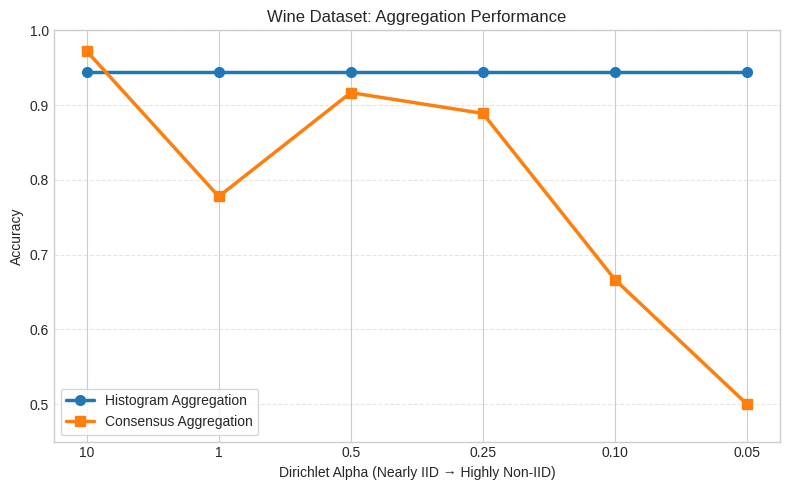

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Results
labels = ["10", "1", "0.5", "0.25", "0.10", "0.05"]
x = np.arange(len(labels))

histogram = histogram_results
consensus = consensus_results

plt.figure(figsize=(8,5))

plt.plot(
    x,
    histogram,
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Histogram Aggregation"
)

plt.plot(
    x,
    consensus,
    marker="s",
    markersize=7,
    linewidth=2.5,
    label="Consensus Aggregation"
)

plt.xticks(x, labels)

plt.xlabel("Dirichlet Alpha (Nearly IID → Highly Non-IID)")
plt.ylabel("Accuracy")
plt.title("Wine Dataset: Aggregation Performance")

plt.ylim(0.45, 1.0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend(frameon=True)

plt.tight_layout()

plt.show()

In [ ]:
results["Histogram"] = results["Histogram"].round(4)

results["Consensus"] = results["Consensus"].round(4)

results

,Alpha,Histogram,Consensus
0,10.00,0.9444,0.9722
1,1.00,0.9444,0.7778
2,0.50,0.9444,0.9167
3,0.25,0.9444,0.8889
4,0.10,0.9444,0.6667
5,0.05,0.9444,0.5000


# Experimental Results

The proposed histogram-based federated decision tree was evaluated under multiple levels of statistical heterogeneity generated using Dirichlet partitioning.

Two aggregation strategies were compared:

- Histogram Aggregation
- Consensus Histogram Aggregation

The Dirichlet concentration parameter (α) was gradually reduced from 10 to 0.05 to simulate increasingly heterogeneous client data distributions.

The obtained accuracies indicate that the Histogram Aggregation approach maintained a nearly constant classification accuracy across all evaluated α values. In contrast, the Consensus Aggregation method exhibited greater sensitivity to the degree of statistical heterogeneity, achieving its highest performance under nearly IID conditions while showing noticeable performance degradation as the client distributions became increasingly skewed.

These results demonstrate that the aggregation strategy has a measurable influence on model performance under Non-IID data distributions.

# Discussion

Several observations can be drawn from the experimental results.

Under nearly IID settings (α = 10), both aggregation strategies achieved high classification accuracy, with the Consensus Aggregation method slightly outperforming simple histogram summation.

As the degree of statistical heterogeneity increased (smaller α values), the Consensus Aggregation approach showed a gradual reduction in classification accuracy. This behaviour suggests that median-based consensus aggregation may discard useful local statistical information when only a few clients contain representative samples of particular classes.

In contrast, the Histogram Aggregation approach produced almost identical accuracy across all evaluated α values. Although this demonstrates stable behaviour in the current implementation, such invariance is uncommon in federated learning literature, where increasing heterogeneity typically leads to performance degradation.

This observation indicates that the present implementation still retains characteristics similar to centralized tree construction. Consequently, the influence of client heterogeneity is partially masked, reducing the expected sensitivity of the model to decreasing α values.

# Current Limitations

The present implementation represents an initial prototype of a privacy-aware federated decision tree.

Several limitations remain:

- Histogram bins are generated using fixed-width intervals rather than adaptive quantile-based partitions.
- The server still reconstructs global histogram statistics at every recursive tree node, making the implementation closer to a simulated federated environment than a fully decentralized protocol.
- Only the Wine dataset was evaluated, which is relatively small and contains limited feature complexity.
- Each aggregation strategy was evaluated on a classical decision tree without additional privacy mechanisms such as differential privacy or secure aggregation.

These limitations provide several opportunities for future improvements.

# Future Work

The current implementation establishes the basic framework for histogram-based federated decision tree learning.

Future work will extend this framework in several directions.

First, experiments will be conducted on larger and more complex datasets to better evaluate the robustness of the proposed aggregation strategies under realistic heterogeneous environments.

Second, adaptive histogram construction methods, such as quantile-based or entropy-guided binning, will be investigated to improve split quality.

Third, stronger privacy-preserving mechanisms, including secure aggregation and differential privacy, will be incorporated so that only encrypted or noise-protected histogram statistics are exchanged between clients and the server.

Finally, additional aggregation strategies and ensemble-based federated tree methods will be explored to improve both robustness and classification performance under highly Non-IID client distributions.

# Conclusion

This notebook presented a privacy-aware histogram-based federated decision tree that constructs decision trees using only aggregated client-side histogram statistics instead of directly sharing raw training data.

Two aggregation strategies, namely Histogram Aggregation and Consensus Histogram Aggregation, were implemented and evaluated under multiple degrees of statistical heterogeneity using Dirichlet partitioning.

The experiments demonstrated that both approaches achieve competitive performance under nearly IID client distributions. As statistical heterogeneity increased, the Consensus Aggregation method exhibited greater sensitivity to client imbalance, whereas the Histogram Aggregation approach remained comparatively stable in the current implementation.

Although the proposed framework successfully demonstrates the feasibility of histogram-based federated decision tree learning, additional improvements are required to fully capture the effects of highly heterogeneous client distributions and stronger privacy constraints.

Overall, this work provides a modular foundation for developing more robust and privacy-preserving federated tree learning algorithms that can be extended to larger datasets and more realistic federated environments.